Polish the object.

In [ ]:
import sys
sys.path.insert(0, '../lib')

import os
import scvi
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import anndata as ad
import pynndescent
import numba
import seaborn as sns
import torch
import pytorch_lightning.loggers
import rapids_singlecell as rsc
import sc_utils
import gc
import shutil

import common_data

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (


In [ ]:
pd.options.display.max_rows = 100

In [3]:
%config InlineBackend.figure_format = "retina"

## Load object

In [ ]:
adata = sc.read_h5ad(common_data._sc_root / '07c_1000_10-3/07c_1000_10-3.h5ad')

In [76]:
adata.shape

(2452841, 1000)

In [77]:
adata.raw.shape

(2452841, 19488)

In [79]:
adata.obs.cell_type.nunique()

37

Text(0.5, 1.0, 'Number of cells per library')

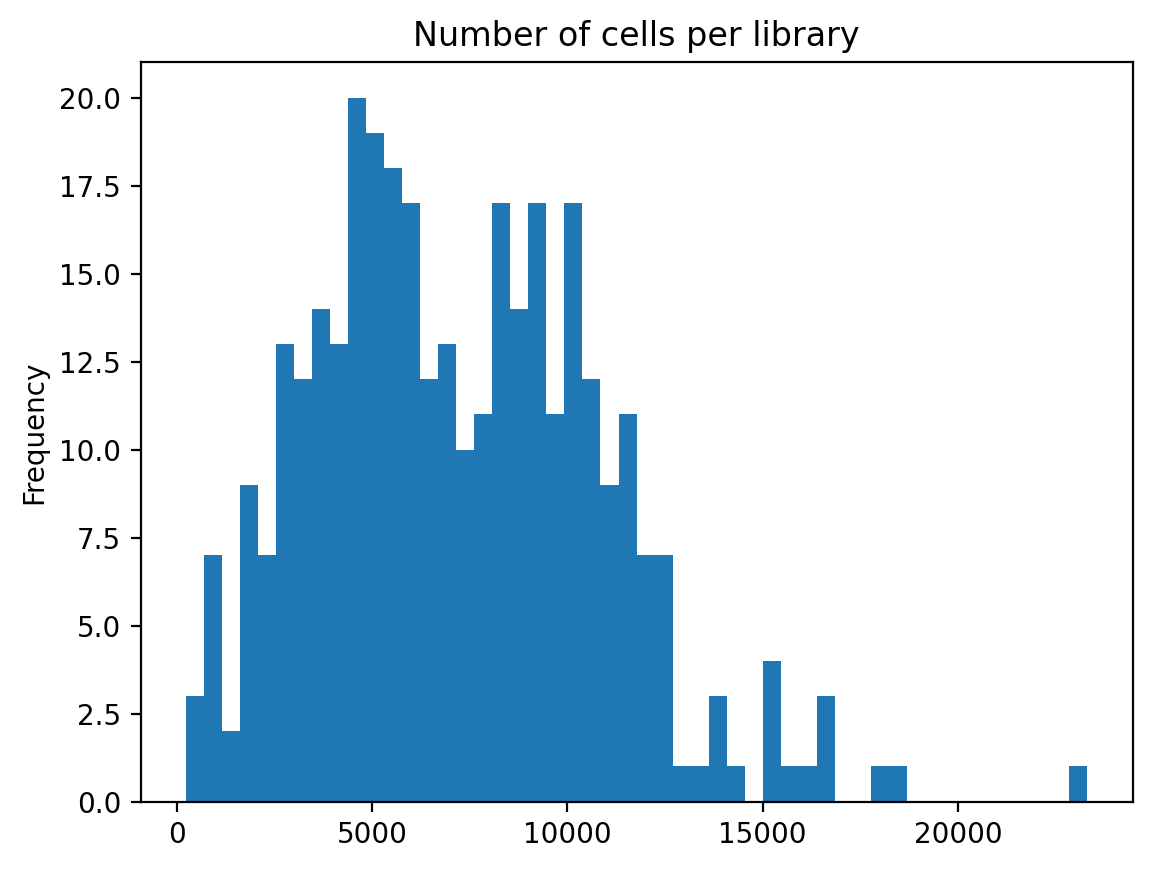

In [5]:
ax = adata.obs.groupby('library_id').size().plot.hist(bins=50)
ax.set_title('Number of cells per library')

Text(0.5, 1.0, 'Number of cells per sample')

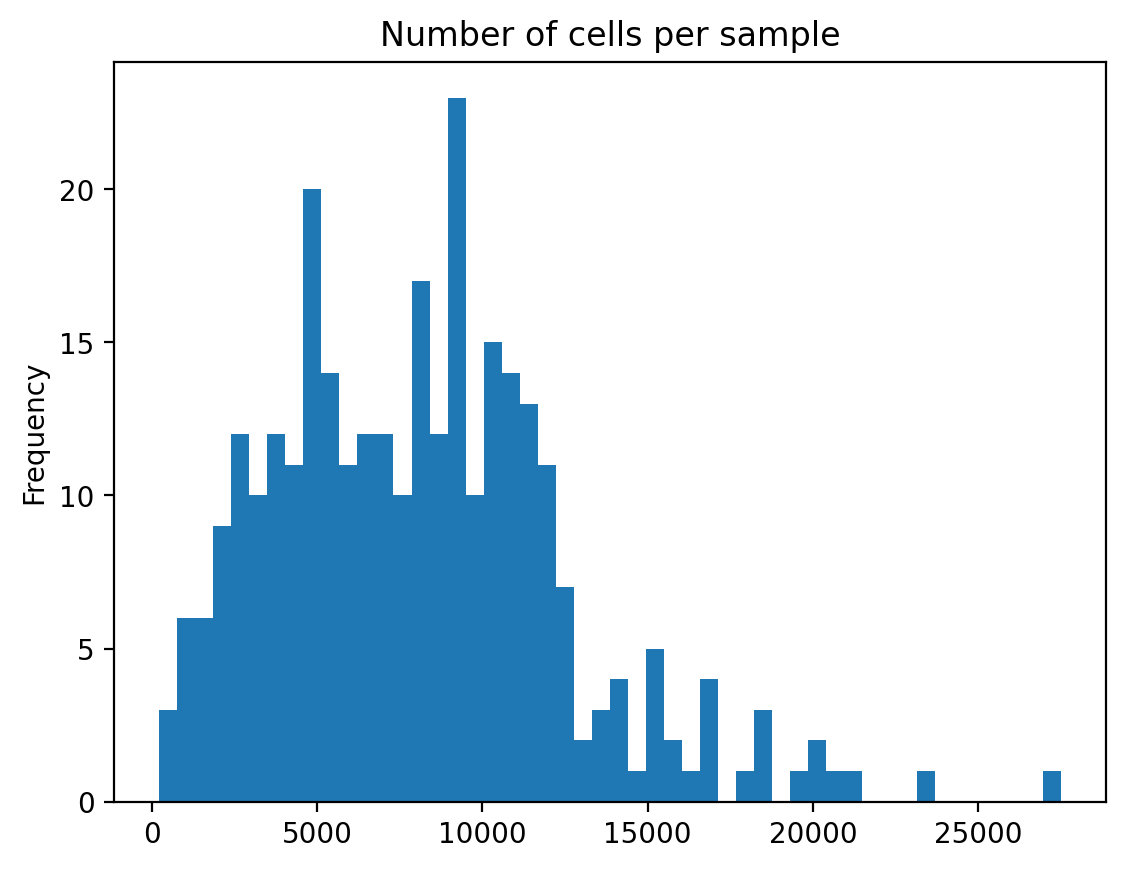

In [6]:
ax = adata.obs.groupby('individual').size().plot.hist(bins=50)
ax.set_title('Number of cells per sample')

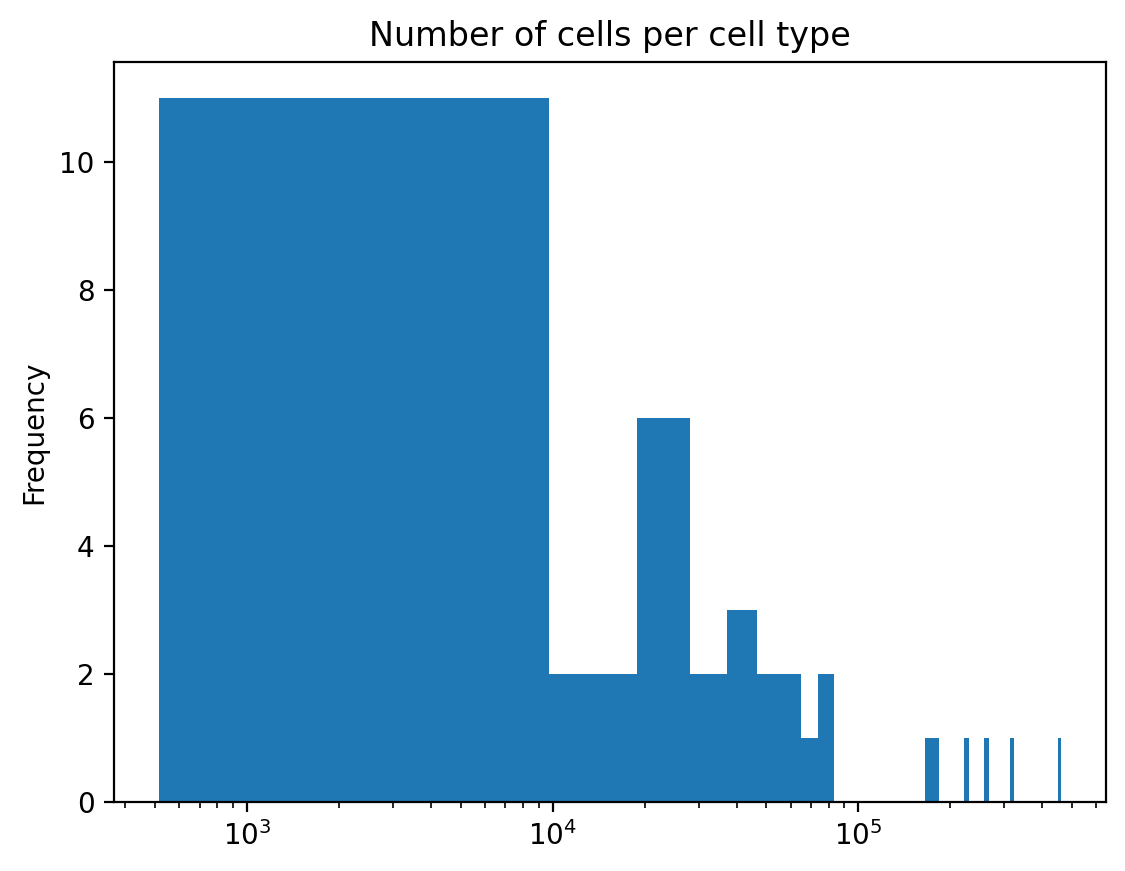

In [7]:
ax = adata.obs.groupby('cell_type').size().plot.hist(bins=50)
ax.set_title('Number of cells per cell type')
ax.set_xscale('log')

In [8]:
adata.obs.cell_type.value_counts()

TRAM-1 FABP4                       459355
CD8 T cells                        314690
CD4 T cells                        259484
MoAM-3                             229056
MoAM-1                             182595
Monocytes-2 IL1B                   170762
MoAM-5                              80493
TRAM-4 FABP4                        76087
MoAM-2                              73071
Proliferating plasma cells          61912
TRAM-3 FABP4                        58872
TRAM-2 FABP4                        49909
gdT cells                           49362
MoAM-6                              43975
Monocytes-1                         41042
Macrophages                         39598
Proliferating macrophages           29563
DC2                                 29086
Proliferating CD4 T cells           26676
MoAM-7                              24653
MoAM-8                              22417
Perivascular macrophages            21562
Ciliated cells                      21271
Tregs                             

In [ ]:
meta = pd.read_csv(common_data.SC_LABELS, index_col=0)

In [10]:
meta.bal_barcode.duplicated().sum()

0

In [11]:
merged = adata.obs.merge(meta, left_on='individual', right_on='bal_barcode', how='left')

In [12]:
merged.bal_barcode.nunique() - meta.bal_barcode.nunique()

0

In [13]:
merged.index = adata.obs_names

In [35]:
adata.obs = merged.copy()

## Deal with NAs, cause https://github.com/scverse/anndata/issues/679

Duh!

In [36]:
idx = adata.obs.patient.notna()
adata.obs.loc[idx, 'patient_str'] = adata.obs.patient[idx].astype(int).astype(str)

In [37]:
idx = adata.obs.patient.isna()
adata.obs.loc[idx, 'patient_str'] = adata.obs.individual[idx]

In [39]:
adata.obs.drop(columns='patient', inplace=True)
adata.obs.rename(columns={'patient_str': 'patient'}, inplace=True)

In [40]:
num_columns = [
    'ICU_stay', 'ICU_day', 'SOFA_score', 'Immunocompromised_flag', 'External_transfer_flag',
    'Binary_outcome', 'day_of_hospitalization', 'week_of_hospitalization', 'num_pathogens',
    'prev_num_pathogens',
]
for col in num_columns:
    adata.obs[col].fillna(-1, inplace=True)

In [41]:
adata.obs.drop(columns=[
    'BAL_pct_neutrophils', 'Sc_GEX_sequenced', 'non_pneu_control',
    'non_pneu_infiltrate', 'non_pneu_infection', 'non_pneu_kn_cond',
    'other_non_pneu_infection', 'prev_bal_idx', 'prev_bal_idx_pt',
    'first_episode_id'
], inplace=True)

In [42]:
idx = adata.obs.bal_barcode.isna()
adata.obs.bal_barcode = adata.obs.bal_barcode.astype(str)
adata.obs.loc[idx, 'bal_barcode'] = adata.obs.individual[idx]
adata.obs.bal_barcode = adata.obs.bal_barcode.astype('category')
adata.obs.loc[idx, 'cohort'] = 'SCRIPT'
adata.obs.loc[idx, 'is_healthy_control'] = False
adata.obs.loc[idx, 'is_npc_with_fungi'] = False
adata.obs.loc[idx, 'is_npc_control'] = False
adata.obs.loc[idx, 'is_culture_negative_pneumonia'] = False
adata.obs.loc[idx, 'is_long_covid'] = False
adata.obs.loc[idx, 'cellot_groups'] = 'discard'

In [47]:
adata.obs.Episode_id.fillna('none', inplace=True)
adata.obs.Discharge_disposition.fillna('NA', inplace=True)
adata.obs.Episode_etiology.fillna('NA', inplace=True)
adata.obs.episode_type.fillna('NA', inplace=True)
adata.obs.clinical_opinion_l1.fillna('NA', inplace=True)
adata.obs.clinical_opinion_l2.fillna('NA', inplace=True)
adata.obs.pathogen_groups.fillna('NA', inplace=True)
adata.obs.future_episode_outcome.fillna('not-relevant', inplace=True)
adata.obs.future_vap_onset.fillna('NA', inplace=True)
adata.obs.viral_pathogen.fillna('NA', inplace=True)
adata.obs.prev_episode_type.fillna('NA', inplace=True)
adata.obs.first_episode_type.fillna('NA', inplace=True)
adata.obs.prev_pathogen_groups.fillna('NA', inplace=True)
adata.obs.ep_num.fillna(0, inplace=True)

In [45]:
bool_columns = [
    'test_performed', 'clear_cut', 'prev_test_performed', 'prev_clear_cut',
    'neutrophils_greater_50'
]
for col in bool_columns:
    adata.obs[col] = adata.obs[col].astype(float).fillna(-1).astype(int)

In [48]:
idx = adata.obs.bal_num.isna()
bals_per_pt = adata.obs.loc[idx].groupby('patient').individual.nunique()
adata.obs.loc[idx, 'bal_num'] = bals_per_pt[adata.obs.patient[idx]].values

In [57]:
adata.obs.is_healthy_control = adata.obs.is_healthy_control.astype(bool)
adata.obs.is_npc_with_fungi = adata.obs.is_npc_with_fungi.astype(bool)
adata.obs.is_npc_control = adata.obs.is_npc_control.astype(bool)
adata.obs.is_culture_negative_pneumonia = adata.obs.is_culture_negative_pneumonia.astype(bool)
adata.obs.is_long_covid = adata.obs.is_long_covid.astype(bool)

In [ ]:
BASE = common_data._sc_root / '08_rc1/'
os.makedirs(BASE, exist_ok=True)

In [66]:
adata.write_h5ad(
    BASE + '/08_rc1_full.h5ad'
)

In [67]:
adata.obs.to_csv(BASE + '/08_rc1_full-metadata.csv')

In [69]:
downsampled = adata.obs.sample(frac=0.1, random_state=1066).index

In [73]:
adata[downsampled].write_h5ad(
    BASE + '/08_rc1.h5ad'
)

In [74]:
adata[downsampled].obs.to_csv(BASE + '/08_rc1-metadata.csv')

In [ ]:
shutil.copy2(
    common_data._sc_root / '07c_1000_10-3/07c_1000_10-3-markers.csv',
    BASE + '/08_rc1-markers.csv'
)